In [40]:
import sys, os
print(os.getcwd())
print(sorted(os.listdir()))

/content/drive/MyDrive/github/quant_dev/notebooks
['test_es.ipynb', 'test_ko.ipynb', 'test_ta_packages.ipynb']


In [41]:
# Google Colab

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/github/quant_dev/notebooks')
print(sorted(os.listdir()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test_es.ipynb', 'test_ko.ipynb', 'test_ta_packages.ipynb']


In [42]:
# Add the parent directory to the sys.path
sys.path.append(
    os.path.dirname(
        os.path.dirname(os.path.abspath(__file__))
        if "__file__" in globals().keys()
        else os.getcwd()
    )
)

In [43]:
from src.tools.basic import *

# ES analysis

In [44]:
start_date = '2016-01-01'
end_date = dt.datetime.strftime(dt.datetime.today(), "%Y-%m-%d")
trade_d = 250

In [45]:
# Note
# Dow Jones Industrial Average (DJIA) → ^DJI
# S&P 500 Index → ^GSPC
# Nasdaq Composite Index → ^IXIC
# Russell 2000 Index → ^RUT

stock = 'ES=F'
data = yf.download(stock, start_date, end_date)

/tmp/ipykernel_29860/2372853104.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


In [46]:
for d in [1, 2, 3, 4, 5, 10, 250]:
  if d == 1:
    data["PCT Change 1"] = data["Close"].pct_change()
    data["PCT Change 1 Av"] = data["PCT Change 1"].rolling(trade_d).mean()
    data["PCT Change 1 STD"] = data["PCT Change 1"].rolling(trade_d).std()

  else:
    data[f"PCT Change {d}"] = data["PCT Change 1"].rolling(d).sum()
    data[f"PCT Change {d} Av"] = data[f"PCT Change {d}"].rolling(trade_d).mean()
    data[f"PCT Change {d} STD"] = data[f"PCT Change {d}"].rolling(trade_d).std()

  data["PCT Change Annualized"] = data["PCT Change 1"].rolling(trade_d).sum()
  data["PCT Change Annualized STD"] = data["PCT Change 1 STD"] * trade_d ** 0.5

pct_change = data["PCT Change 1"]


In [47]:
data.tail()

Price,Close,High,Low,Open,Volume,PCT Change 1,PCT Change 1 Av,PCT Change 1 STD,PCT Change Annualized,PCT Change Annualized STD,PCT Change 2,PCT Change 2 Av,PCT Change 2 STD,PCT Change 3,PCT Change 3 Av,PCT Change 3 STD,PCT Change 4,PCT Change 4 Av,PCT Change 4 STD,PCT Change 5,PCT Change 5 Av,PCT Change 5 STD,PCT Change 10,PCT Change 10 Av,PCT Change 10 STD,PCT Change 250,PCT Change 250 Av,PCT Change 250 STD
Ticker,ES=F,ES=F,ES=F,ES=F,ES=F,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-24,7194.75,7200.50,7135.50,7143.00,1463962,0.007174,0.001068,0.007892,0.266890,0.124780,0.003305,0.002109,0.010979,0.013340,0.003193,0.013369,0.006625,0.004319,0.015211,0.004740,0.005537,0.017066,0.048667,0.011276,0.024055,0.266890,0.161807,0.039169
2026-04-27,7206.00,7211.25,7171.50,7185.00,1085690,0.001564,0.001052,0.007887,0.262916,0.124700,0.008738,0.002119,0.010984,0.004868,0.003160,0.013354,0.014904,0.004245,0.015114,0.008188,0.005371,0.016835,0.040384,0.011329,0.024105,0.262916,0.162393,0.039581
2026-04-28,7171.00,7223.25,7146.25,7204.75,1361467,-0.004857,0.001030,0.007896,0.257477,0.124839,-0.003293,0.002082,0.010986,0.003881,0.003149,0.013353,0.000011,0.004190,0.015104,0.010047,0.005275,0.016739,0.023682,0.011303,0.024088,0.257477,0.162939,0.039947
2026-04-29,7168.00,7190.75,7131.25,7172.50,1361467,-0.000418,0.001002,0.007888,0.250570,0.124727,-0.005275,0.002032,0.010991,-0.003712,0.003084,0.013346,0.003463,0.004151,0.015093,-0.000407,0.005193,0.016716,0.015305,0.011128,0.023898,0.250570,0.163467,0.040230
2026-04-30,7253.75,7263.50,7246.25,7256.00,21258,0.011963,0.000989,0.007867,0.247284,0.124393,0.011545,0.001991,0.010937,0.006687,0.003021,0.013292,0.008251,0.004073,0.015020,0.015425,0.005141,0.016664,0.024931,0.010936,0.023589,0.247284,0.163970,0.040488


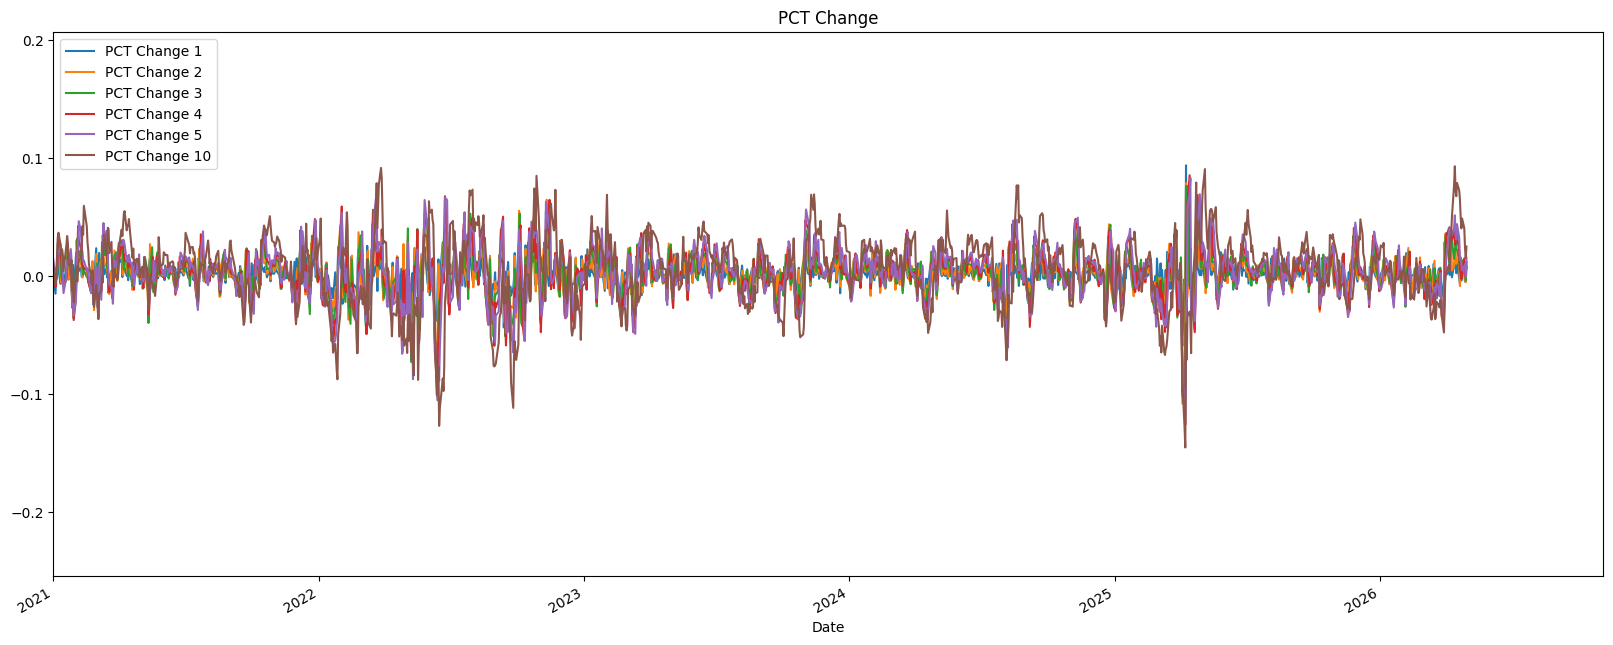

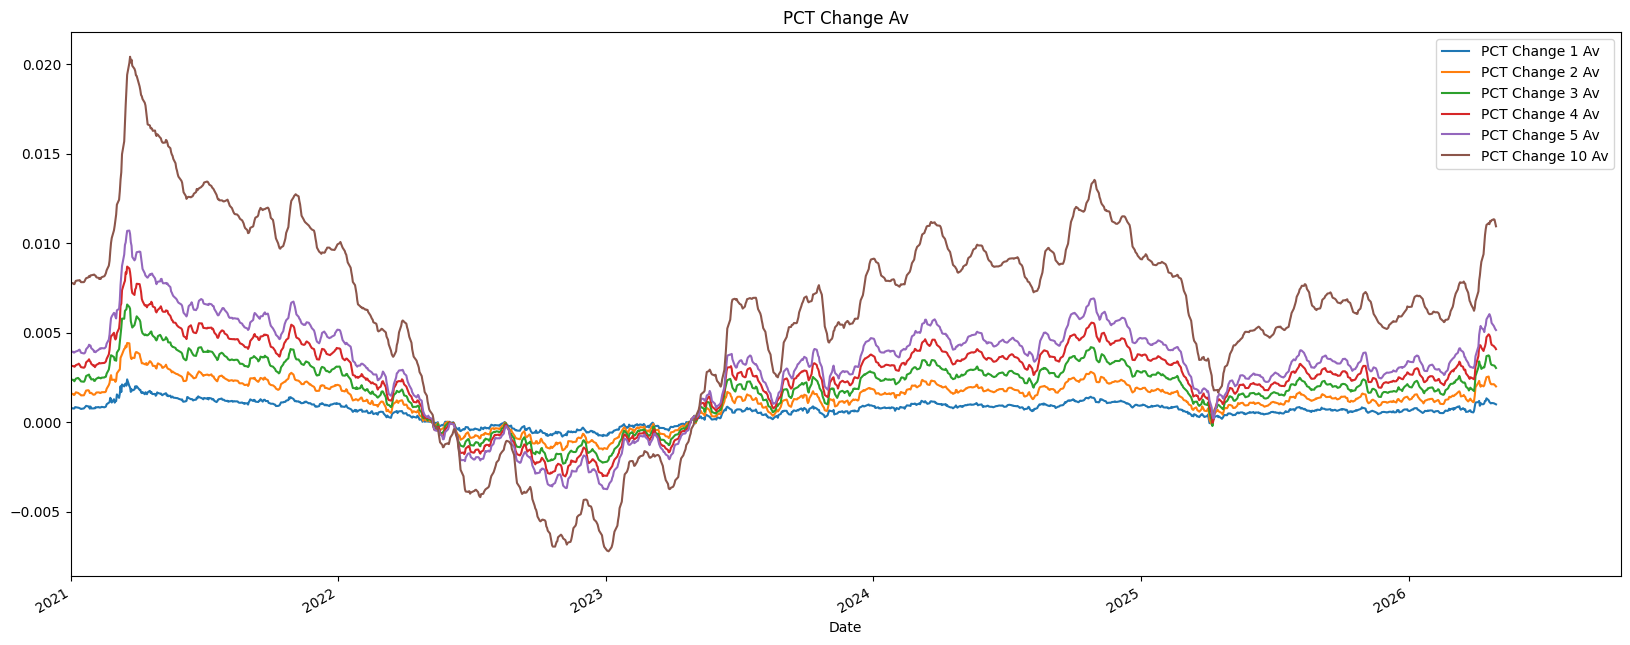

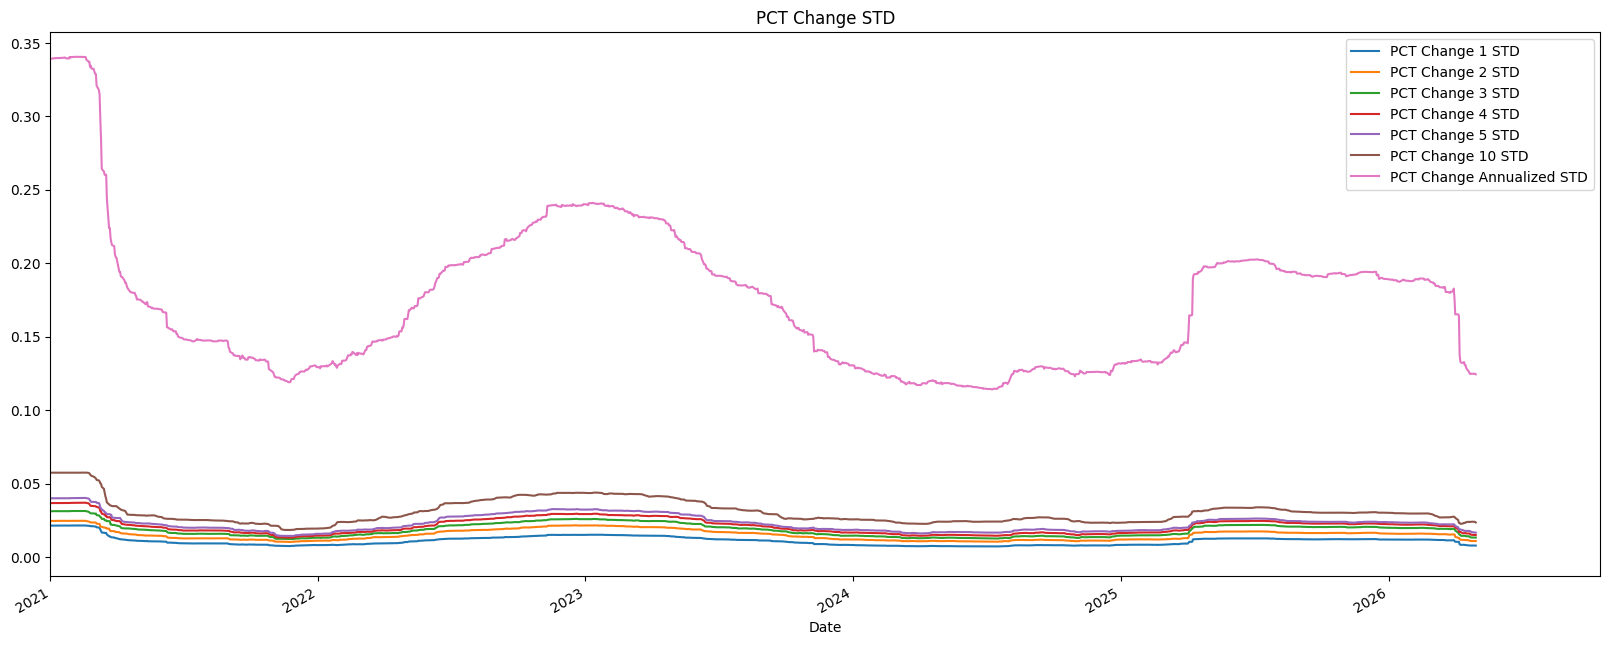

In [48]:
# @ Plots
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d}"].plot(kind='line', label=f"PCT Change {d}")

plt.xlim(dt.datetime(2021,1,1),)
plt.title("PCT Change")
plt.legend()
plt.show()

plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d} Av"].plot(kind='line', label=f"PCT Change {d} Av")

plt.xlim(dt.datetime(2021,1,1),)
plt.title("PCT Change Av")
plt.legend()
plt.show()

plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d} STD"].plot(kind='line', label=f"PCT Change {d} STD")

data["PCT Change Annualized STD"].plot(kind='line', label="PCT Change Annualized STD")

plt.title("PCT Change STD")
plt.xlim(dt.datetime(2021,1,1),)
plt.legend()
plt.show()

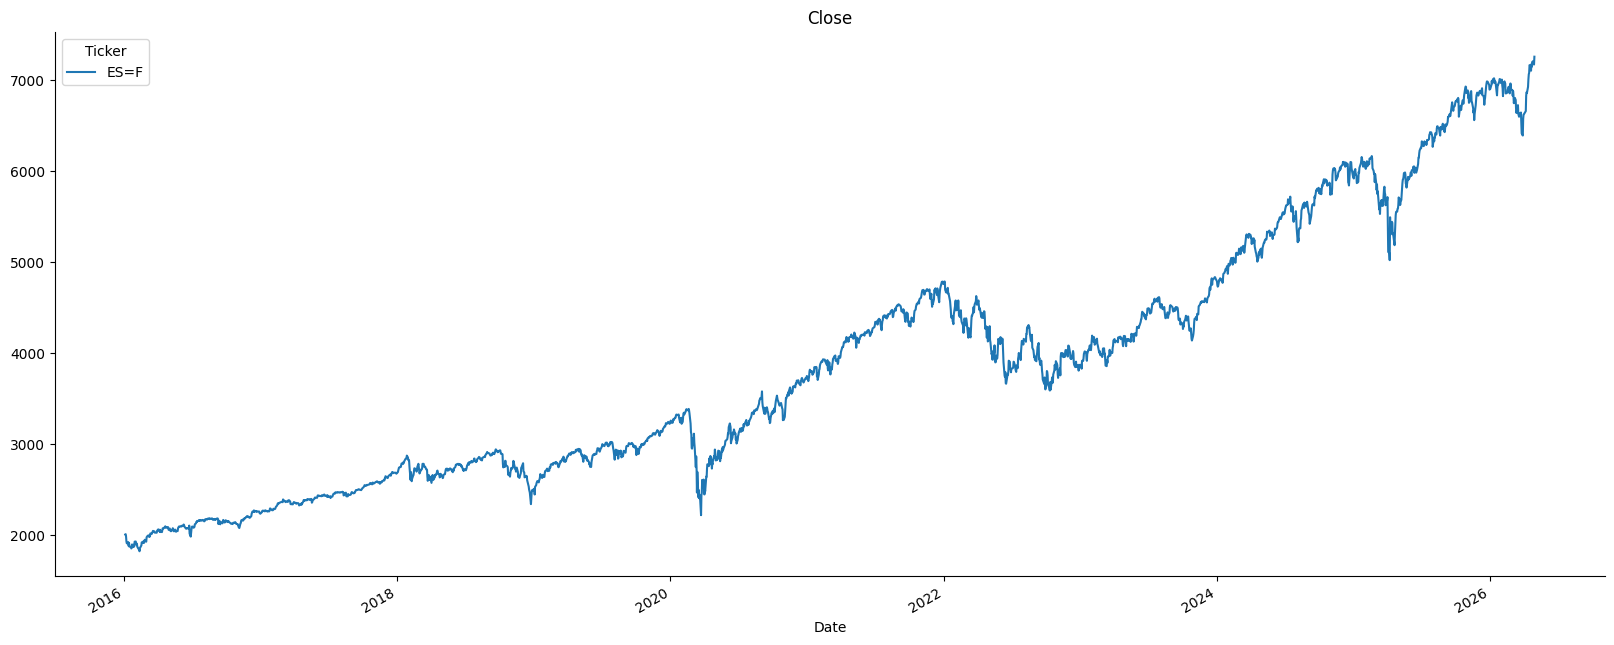

In [49]:
# @title Close

from matplotlib import pyplot as plt
data['Close'].plot(kind='line', figsize=(20, 8), title='Close')
plt.gca().spines[['top', 'right']].set_visible(False)

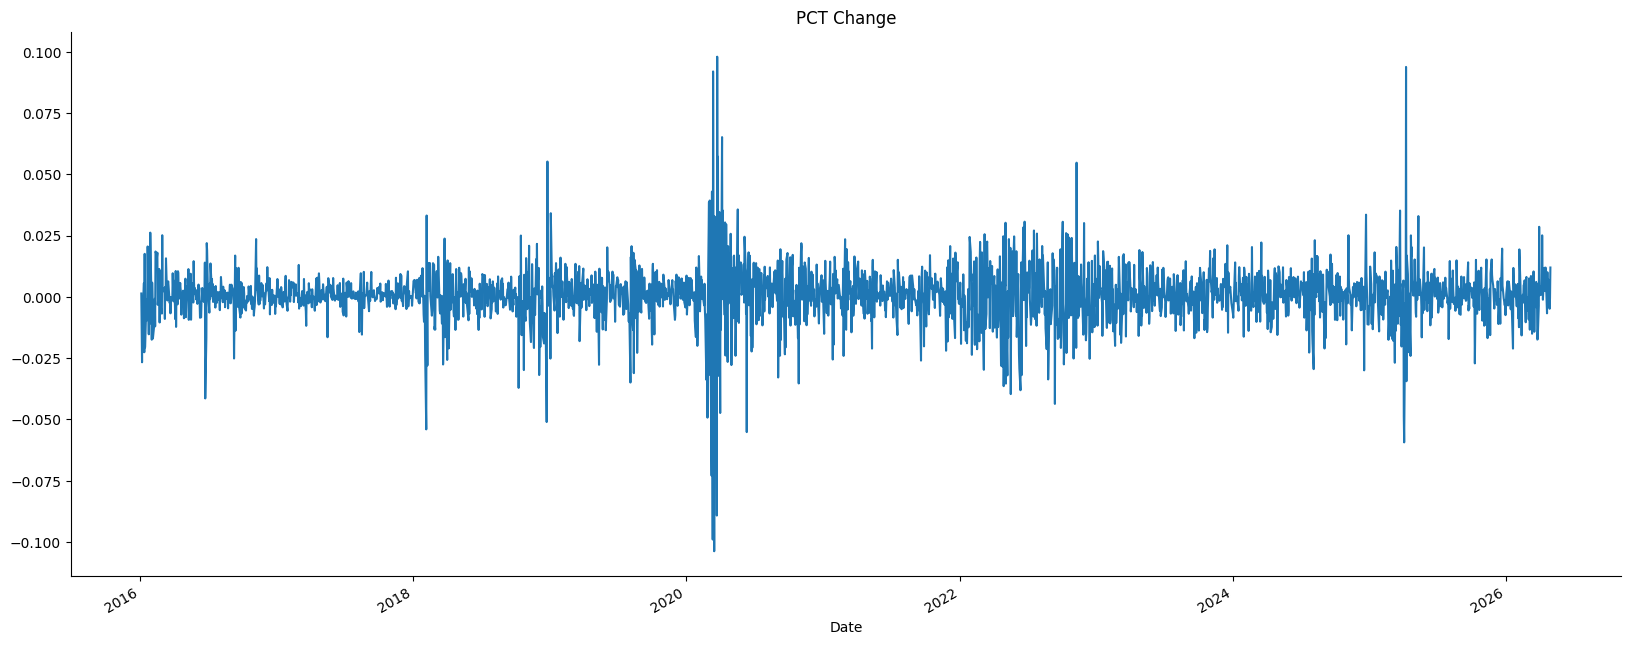

In [50]:
# @title PCT Change

from matplotlib import pyplot as plt
data['PCT Change 1'].plot(kind='line', figsize=(20, 8), title='PCT Change')
plt.gca().spines[['top', 'right']].set_visible(False)

In [51]:
print(f"Min pct change: {pct_change.min()}")
print(f"Max pct change: {pct_change.max()}")

Min pct change: -0.10376483679525228
Max pct change: 0.09795091195676653


# Vol and mean

## Annualized

In [52]:
data["PCT Change Annualized"].iloc[-1]

np.float64(0.24728373646713908)

In [53]:
data["PCT Change Annualized STD"].iloc[-1]

np.float64(0.124392860156647)

## Daily

In [54]:
data.iloc[-1]

,,2026-04-30
Price,Ticker,
Close,ES=F,7253.750000
High,ES=F,7263.500000
Low,ES=F,7246.250000
Open,ES=F,7256.000000
Volume,ES=F,21258.000000
PCT Change 1,,0.011963
PCT Change 1 Av,,0.000989
PCT Change 1 STD,,0.007867
PCT Change Annualized,,0.247284


In [55]:
sd = data["PCT Change 1 STD"].iloc[-1]
# sd = pct_change[-250:].std()
sd

np.float64(0.007867295255156281)

In [56]:
mu = data["PCT Change 1 Av"].iloc[-1]
# mu = pct_change[-250:].mean()
mu

np.float64(0.0009891349458685562)

# Historical analysis

In [57]:
sd_his = data["PCT Change 1"].dropna().std()
# sd_his = pct_change.dropna().std()
sd_his

0.01136323357748946

In [58]:
# Threshold daily volatility
sd_th = 0.01

In [59]:
df_his = pd.DataFrame()

for sd in [0.05, 0.045, 0.04, 0.035, 0.03, 0.025, 0.02, 0.015, 0.01, 0.005, 0.002, 0.001, 0.0001]:
  for n_y in [2,5]:
    for n_d in [1,2,3,4,5,10,20,30]:
      df = consecutive_analysis(pct_change, sd, n_d, n_y, return_output=True)
      df_his = pd.concat([df_his, df])
    print()

df_his.reset_index(drop=True, inplace=True)

Consecutive change of above 5.00% for 1 days in the last 2 years:
Probability 0.2% Last occured on 2025-04-09
Consecutive change of below 5.00% for 1 days in the last 2 years:
Probability 0.2% Last occured on 2025-04-04
Cumulative change of above 5.00% in 1 days in the last 2 years:
Probability 0.2% Last occured on 2025-04-09
Cumulative change of below 5.00% in 1 days in the last 2 years:
Probability 0.2% Last occured on 2025-04-04
Consecutive change of above 5.00% for 2 days in the last 2 years:
Probability 0.0% 
Consecutive change of below 5.00% for 2 days in the last 2 years:
Probability 0.0% 
Cumulative change of above 5.00% in 2 days in the last 2 years:
Probability 0.4% Last occured on 2025-04-10
Cumulative change of below 5.00% in 2 days in the last 2 years:
Probability 0.4% Last occured on 2025-04-07
Consecutive change of above 5.00% for 3 days in the last 2 years:
Probability 0.0% 
Consecutive change of below 5.00% for 3 days in the last 2 years:
Probability 0.0% 
Cumulative c

In [60]:
data.tail()

Price,Close,High,Low,Open,Volume,PCT Change 1,PCT Change 1 Av,PCT Change 1 STD,PCT Change Annualized,PCT Change Annualized STD,PCT Change 2,PCT Change 2 Av,PCT Change 2 STD,PCT Change 3,PCT Change 3 Av,PCT Change 3 STD,PCT Change 4,PCT Change 4 Av,PCT Change 4 STD,PCT Change 5,PCT Change 5 Av,PCT Change 5 STD,PCT Change 10,PCT Change 10 Av,PCT Change 10 STD,PCT Change 250,PCT Change 250 Av,PCT Change 250 STD
Ticker,ES=F,ES=F,ES=F,ES=F,ES=F,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-24,7194.75,7200.50,7135.50,7143.00,1463962,0.007174,0.001068,0.007892,0.266890,0.124780,0.003305,0.002109,0.010979,0.013340,0.003193,0.013369,0.006625,0.004319,0.015211,0.004740,0.005537,0.017066,0.048667,0.011276,0.024055,0.266890,0.161807,0.039169
2026-04-27,7206.00,7211.25,7171.50,7185.00,1085690,0.001564,0.001052,0.007887,0.262916,0.124700,0.008738,0.002119,0.010984,0.004868,0.003160,0.013354,0.014904,0.004245,0.015114,0.008188,0.005371,0.016835,0.040384,0.011329,0.024105,0.262916,0.162393,0.039581
2026-04-28,7171.00,7223.25,7146.25,7204.75,1361467,-0.004857,0.001030,0.007896,0.257477,0.124839,-0.003293,0.002082,0.010986,0.003881,0.003149,0.013353,0.000011,0.004190,0.015104,0.010047,0.005275,0.016739,0.023682,0.011303,0.024088,0.257477,0.162939,0.039947
2026-04-29,7168.00,7190.75,7131.25,7172.50,1361467,-0.000418,0.001002,0.007888,0.250570,0.124727,-0.005275,0.002032,0.010991,-0.003712,0.003084,0.013346,0.003463,0.004151,0.015093,-0.000407,0.005193,0.016716,0.015305,0.011128,0.023898,0.250570,0.163467,0.040230
2026-04-30,7253.75,7263.50,7246.25,7256.00,21258,0.011963,0.000989,0.007867,0.247284,0.124393,0.011545,0.001991,0.010937,0.006687,0.003021,0.013292,0.008251,0.004073,0.015020,0.015425,0.005141,0.016664,0.024931,0.010936,0.023589,0.247284,0.163970,0.040488


In [61]:
# 1 Day
df = df_his.query("n_days == 1").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
0,consecutive,above,5.00%,1,2,0.002,Last occured on 2025-04-09
1,consecutive,below,5.00%,1,2,0.002,Last occured on 2025-04-04
2,cumulative,above,5.00%,1,2,0.002,Last occured on 2025-04-09
3,cumulative,below,5.00%,1,2,0.002,Last occured on 2025-04-04
32,consecutive,above,5.00%,1,5,0.002,Last occured on 2025-04-09
...,...,...,...,...,...,...,...
451,cumulative,below,1.50%,1,2,0.058,Last occured on 2026-03-27
480,consecutive,above,1.50%,1,5,0.066,Last occured on 2026-04-08
481,consecutive,below,1.50%,1,5,0.064,Last occured on 2026-03-27
482,cumulative,above,1.50%,1,5,0.066,Last occured on 2026-04-08


In [62]:
# 2 Day
df = df_his.query("n_days == 2").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
4,consecutive,above,5.00%,2,2,0.000,
5,consecutive,below,5.00%,2,2,0.000,
6,cumulative,above,5.00%,2,2,0.004,Last occured on 2025-04-10
7,cumulative,below,5.00%,2,2,0.004,Last occured on 2025-04-07
36,consecutive,above,5.00%,2,5,0.000,
...,...,...,...,...,...,...,...
549,consecutive,below,1.00%,2,5,0.020,Last occured on 2026-03-27
580,consecutive,above,0.50%,2,2,0.064,Last occured on 2026-04-15
581,consecutive,below,0.50%,2,2,0.040,Last occured on 2026-03-27
612,consecutive,above,0.50%,2,5,0.086,Last occured on 2026-04-15


In [63]:
# 3 Day
df = df_his.query("n_days == 3").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
8,consecutive,above,5.00%,3,2,0.000,
9,consecutive,below,5.00%,3,2,0.000,
10,cumulative,above,5.00%,3,2,0.006,Last occured on 2025-04-24
11,cumulative,below,5.00%,3,2,0.008,Last occured on 2025-04-08
40,consecutive,above,5.00%,3,5,0.000,
...,...,...,...,...,...,...,...
713,consecutive,below,0.10%,3,2,0.048,Last occured on 2026-03-30
744,consecutive,above,0.10%,3,5,0.096,Last occured on 2026-04-17
745,consecutive,below,0.10%,3,5,0.074,Last occured on 2026-03-30
777,consecutive,below,0.01%,3,2,0.082,Last occured on 2026-03-30


In [64]:
# 4 Day
df = df_his.query("n_days == 4").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
12,consecutive,above,5.00%,4,2,0.000,
13,consecutive,below,5.00%,4,2,0.000,
14,cumulative,above,5.00%,4,2,0.006,Last occured on 2025-04-25
15,cumulative,below,5.00%,4,2,0.008,Last occured on 2025-04-08
44,consecutive,above,5.00%,4,5,0.000,
...,...,...,...,...,...,...,...
748,consecutive,above,0.10%,4,5,0.045,Last occured on 2026-04-17
749,consecutive,below,0.10%,4,5,0.028,Last occured on 2026-03-13
781,consecutive,below,0.01%,4,2,0.032,Last occured on 2026-03-13
812,consecutive,above,0.01%,4,5,0.082,Last occured on 2026-04-17


In [65]:
# 5 Day
df = df_his.query("n_days == 5").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
16,consecutive,above,5.00%,5,2,0.000,
17,consecutive,below,5.00%,5,2,0.000,
18,cumulative,above,5.00%,5,2,0.012,Last occured on 2026-04-14
19,cumulative,below,5.00%,5,2,0.012,Last occured on 2025-04-08
48,consecutive,above,5.00%,5,5,0.000,
...,...,...,...,...,...,...,...
753,consecutive,below,0.10%,5,5,0.006,Last occured on 2024-04-19
784,consecutive,above,0.01%,5,2,0.054,Last occured on 2026-04-17
785,consecutive,below,0.01%,5,2,0.006,Last occured on 2025-08-21
816,consecutive,above,0.01%,5,5,0.042,Last occured on 2026-04-17


In [66]:
# Two weeks
df = df_his.query("n_days == 10").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
20,consecutive,above,5.00%,10,2,0.000,
21,consecutive,below,5.00%,10,2,0.000,
22,cumulative,above,5.00%,10,2,0.054,Last occured on 2026-04-21
23,cumulative,below,5.00%,10,2,0.030,Last occured on 2025-04-16
52,consecutive,above,5.00%,10,5,0.000,
...,...,...,...,...,...,...,...
757,consecutive,below,0.10%,10,5,0.000,
788,consecutive,above,0.01%,10,2,0.000,
789,consecutive,below,0.01%,10,2,0.000,
820,consecutive,above,0.01%,10,5,0.000,


In [67]:
# 1 month
df = df_his.query("n_days == 20").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
24,consecutive,above,5.00%,20,2,0.000,
25,consecutive,below,5.00%,20,2,0.000,
27,cumulative,below,5.00%,20,2,0.062,Last occured on 2026-03-30
56,consecutive,above,5.00%,20,5,0.000,
57,consecutive,below,5.00%,20,5,0.000,
59,cumulative,below,5.00%,20,5,0.095,Last occured on 2026-03-30
88,consecutive,above,4.50%,20,2,0.000,
89,consecutive,below,4.50%,20,2,0.000,
91,cumulative,below,4.50%,20,2,0.066,Last occured on 2026-03-30
120,consecutive,above,4.50%,20,5,0.000,


In [68]:
# 1.5 Months
df = df_his.query("n_days == 30").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
28,consecutive,above,5.00%,30,2,0.000,
29,consecutive,below,5.00%,30,2,0.000,
31,cumulative,below,5.00%,30,2,0.072,Last occured on 2026-03-30
60,consecutive,above,5.00%,30,5,0.000,
61,consecutive,below,5.00%,30,5,0.000,
92,consecutive,above,4.50%,30,2,0.000,
93,consecutive,below,4.50%,30,2,0.000,
95,cumulative,below,4.50%,30,2,0.084,Last occured on 2026-03-30
124,consecutive,above,4.50%,30,5,0.000,
125,consecutive,below,4.50%,30,5,0.000,


In [69]:
p_and_l = {
    1:{"above":[0.15, -0.3], "below": [0.15, -0.3], "exceeding": [0.2, -0.3]},
    5:{"above":[0.2, -0.3], "below": [0.2, -0.3], "exceeding": [0.3, -0.3]},
    10:{"above":[0.2, -0.3], "below": [0.2, -0.3], "exceeding": [0.4, -0.3]},
       }

prob_loss, profit_expect = profit_estimate(
    *sd_and_cond(data, sd_th, 0.02),
    p_and_l, 100)

Default volitality threshold for 1 days: 0.010
Probability of above the limit: 0.096
Profit per contract: 10.68
Probability of below the limit: 0.076
Profit per contract: 11.58
Probability of exceeding the limit: 0.172
Profit per contract: 11.40

1-Year volitality for 1 days: 0.008
Probability of above the limit: 0.132
Profit per contract: 9.06
Probability of below the limit: 0.100
Profit per contract: 10.50
Probability of exceeding the limit: 0.232
Profit per contract: 8.40

Fixed volitality for 1 days: 0.020
Probability of above the limit: 0.016
Profit per contract: 14.28
Probability of below the limit: 0.008
Profit per contract: 14.64
Probability of exceeding the limit: 0.024
Profit per contract: 18.80

Default volitality threshold for 5 days: 0.022
Probability of above the limit: 0.132
Profit per contract: 13.40
Probability of below the limit: 0.056
Profit per contract: 17.20
Probability of exceeding the limit: 0.188
Profit per contract: 18.72

1-Year volitality for 5 days: 0.017
P

In [70]:
p_and_l = {
    1:{"above":[0.15, -1], "below": [0.15, -1], "exceeding": [0.2, -0.9]},
    5:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.3, -0.9]},
    10:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.4, -0.9]},
       }

prob_loss, profit_expect = profit_estimate(
    *sd_and_cond(data, sd_th, 0.02),
    p_and_l, 100)

Default volitality threshold for 1 days: 0.010
Probability of above the limit: 0.096
Profit per contract: 3.96
Probability of below the limit: 0.076
Profit per contract: 6.26
Probability of exceeding the limit: 0.172
Profit per contract: 1.08

1-Year volitality for 1 days: 0.008
Probability of above the limit: 0.132
Profit per contract: -0.18
Probability of below the limit: 0.100
Profit per contract: 3.50
Probability of exceeding the limit: 0.232
Profit per contract: -5.52

Fixed volitality for 1 days: 0.020
Probability of above the limit: 0.016
Profit per contract: 13.16
Probability of below the limit: 0.008
Profit per contract: 14.08
Probability of exceeding the limit: 0.024
Profit per contract: 17.36

Default volitality threshold for 5 days: 0.022
Probability of above the limit: 0.132
Profit per contract: 4.16
Probability of below the limit: 0.056
Profit per contract: 13.28
Probability of exceeding the limit: 0.188
Profit per contract: 7.44

1-Year volitality for 5 days: 0.017
Proba

In [71]:
p_and_l = {
    1:{"above":[0.15, -1], "below": [0.15, -1], "exceeding": [0.2, -0.9]},
    5:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.4, -0.9]},
    10:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.4, -0.9]},
       }
prob_loss, profit_expect = profit_estimate(
    *sd_and_cond(data, sd_th, 0.02),
    p_and_l, 100)

Default volitality threshold for 1 days: 0.010
Probability of above the limit: 0.096
Profit per contract: 3.96
Probability of below the limit: 0.076
Profit per contract: 6.26
Probability of exceeding the limit: 0.172
Profit per contract: 1.08

1-Year volitality for 1 days: 0.008
Probability of above the limit: 0.132
Profit per contract: -0.18
Probability of below the limit: 0.100
Profit per contract: 3.50
Probability of exceeding the limit: 0.232
Profit per contract: -5.52

Fixed volitality for 1 days: 0.020
Probability of above the limit: 0.016
Profit per contract: 13.16
Probability of below the limit: 0.008
Profit per contract: 14.08
Probability of exceeding the limit: 0.024
Profit per contract: 17.36

Default volitality threshold for 5 days: 0.022
Probability of above the limit: 0.132
Profit per contract: 4.16
Probability of below the limit: 0.056
Profit per contract: 13.28
Probability of exceeding the limit: 0.188
Profit per contract: 15.56

1-Year volitality for 5 days: 0.017
Prob

In [72]:
p_and_l = {
    1:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.2, -0.9]},
    5:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.45, -0.9]},
    10:{"above":[0.2, -1], "below": [0.2, -1], "exceeding": [0.45, -0.9]},
       }
prob_loss, profit_expect = profit_estimate(
    *sd_and_cond(data, sd_th, 0.02),
    p_and_l, 100)

Default volitality threshold for 1 days: 0.010
Probability of above the limit: 0.096
Profit per contract: 8.48
Probability of below the limit: 0.076
Profit per contract: 10.88
Probability of exceeding the limit: 0.172
Profit per contract: 1.08

1-Year volitality for 1 days: 0.008
Probability of above the limit: 0.132
Profit per contract: 4.16
Probability of below the limit: 0.100
Profit per contract: 8.00
Probability of exceeding the limit: 0.232
Profit per contract: -5.52

Fixed volitality for 1 days: 0.020
Probability of above the limit: 0.016
Profit per contract: 18.08
Probability of below the limit: 0.008
Profit per contract: 19.04
Probability of exceeding the limit: 0.024
Profit per contract: 17.36

Default volitality threshold for 5 days: 0.022
Probability of above the limit: 0.132
Profit per contract: 4.16
Probability of below the limit: 0.056
Profit per contract: 13.28
Probability of exceeding the limit: 0.188
Profit per contract: 19.62

1-Year volitality for 5 days: 0.017
Prob